In [7]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
BASELINE_PATH = Path("../..") / "data/processed/gse78220/baseline_long.parquet"
df = pd.read_parquet(BASELINE_PATH)
df.head()

,gene_id,expression_sample_key,expression,sample_id,patient_label,response_label,timepoint,dataset_accession
0,A1BG,Pt1.baseline,8.025380,GSM2069823,Pt1,non_responder,baseline,GSE78220
1,A1BG-AS1,Pt1.baseline,0.677503,GSM2069823,Pt1,non_responder,baseline,GSE78220
2,A1CF,Pt1.baseline,0.000000,GSM2069823,Pt1,non_responder,baseline,GSE78220
3,A2M,Pt1.baseline,185.304000,GSM2069823,Pt1,non_responder,baseline,GSE78220
4,A2M-AS1,Pt1.baseline,0.363531,GSM2069823,Pt1,non_responder,baseline,GSE78220


In [3]:
print("rows:", len(df))
print("samples:", df["sample_id"].nunique())
print("genes:", df["gene_id"].nunique())

print("\nresponse counts")
print(
    df[["sample_id", "response_label"]]
    .drop_duplicates()["response_label"]
    .value_counts()
)

rows: 682236
samples: 27
genes: 25268

response counts
response_label
responder        15
non_responder    12
Name: count, dtype: int64


In [4]:
sample_summary = (
    df.groupby(["sample_id", "response_label"], as_index=False)
    .agg(
        n_genes=("gene_id", "nunique"),
        mean_expression=("expression", "mean"),
        median_expression=("expression", "median"),
        zero_fraction=("expression", lambda x: (x == 0).mean()),
    )
    .sort_values(["response_label", "sample_id"])
)

sample_summary

,sample_id,response_label,n_genes,mean_expression,median_expression,zero_fraction
0,GSM2069823,non_responder,25268,149.676924,1.119607,0.226611
5,GSM2069828,non_responder,25268,369.608936,0.807805,0.266305
8,GSM2069831,non_responder,25268,220.139807,1.397190,0.213749
9,GSM2069832,non_responder,25268,337.950347,0.924300,0.237811
11,GSM2069834,non_responder,25268,118.201179,0.960618,0.221901
14,GSM2069838,non_responder,25268,421.902857,1.067022,0.250594
15,GSM2069839,non_responder,25268,105.475830,1.322297,0.217152
16,GSM2069840,non_responder,25268,479.427009,1.269827,0.225859
17,GSM2069841,non_responder,25268,374.057041,0.773445,0.261556
21,GSM2069845,non_responder,25268,293.076408,1.335570,0.225344


In [8]:
expr = df.pivot_table(
    index="sample_id",
    columns="gene_id",
    values="expression",
    aggfunc="mean",
).fillna(0.0)

labels = (
    df[["sample_id", "response_label"]]
    .drop_duplicates()
    .set_index("sample_id")
    .loc[expr.index]
)

expr_log = np.log1p(expr.astype(float))

gene_var = expr_log.var(axis=0)
top_genes = gene_var.nlargest(500).index
expr_filtered = expr_log[top_genes]

X_scaled = StandardScaler().fit_transform(expr_filtered)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    components,
    index=expr_filtered.index,
    columns=["PC1", "PC2"],
).join(labels)

pca_df.head()

,PC1,PC2,response_label
sample_id,,,
GSM2069823,-1.667774,3.566787,non_responder
GSM2069824,15.355568,-5.884047,responder
GSM2069825,-4.473710,0.347084,responder
GSM2069826,-6.916500,-6.661338,responder
GSM2069827,-5.372131,-5.370343,responder


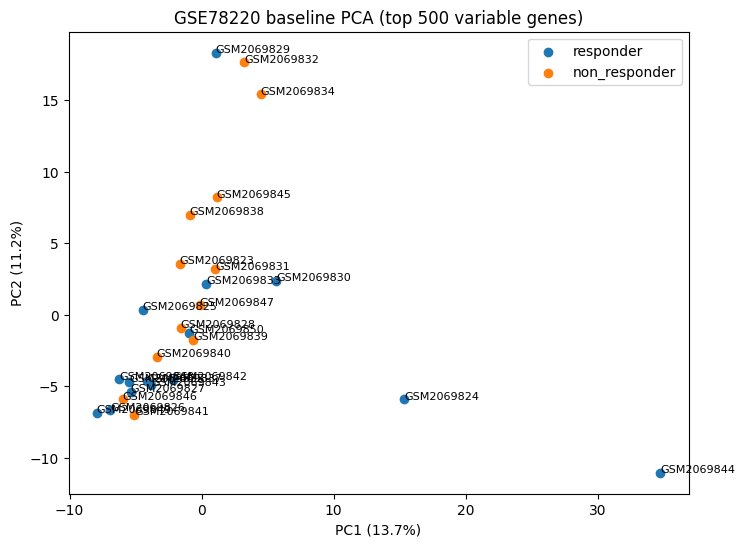

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for label in ["responder", "non_responder"]:
    subset = pca_df[pca_df["response_label"] == label]
    ax.scatter(subset["PC1"], subset["PC2"], label=label)

    for sample_id, row in subset.iterrows():
        ax.annotate(sample_id, (row["PC1"], row["PC2"]), fontsize=8)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("GSE78220 baseline PCA (top 500 variable genes)")
ax.legend()
plt.show()

In [10]:
top_variable_genes = gene_var.nlargest(20).reset_index()
top_variable_genes.columns = ["gene_id", "variance"]
top_variable_genes

,gene_id,variance
0,MIR4461,35.703377
1,MIR663A,35.481769
2,SNORD33,32.484480
3,MIR1234,30.864473
4,SNORD104,28.600846
5,MIR650,19.867160
6,MIR4442,16.611279
7,SNORD47,15.955800
8,MIR3960,15.732597
9,MIR3190,14.896292
